In [1]:
# XGBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Read data

# Chicago 2015–2024 Training Set
train_full = pd.read_csv("chicago_2015_2024_shared_final.csv")
train_X = pd.read_csv("chicago_2015_2024_X_shared_42cols.csv")

# Chicago 2025 Test Set
test_full = pd.read_csv("chicago_2025_shared_final.csv")
test_X = pd.read_csv("chicago_2025_X_shared_42cols.csv")

# Texas external(from NIBRS,Texas 2024)
ext_full = pd.read_csv("data/tx_external_shared_final_42cols.csv")
ext_X = pd.read_csv("data/tx_external_X_shared_42cols.csv")

In [3]:
# Basic check-up
print("train_full shape:", train_full.shape)
print("train_X shape:", train_X.shape)

print("test_full shape:", test_full.shape)
print("test_X shape:", test_X.shape)

print("ext_full shape:", ext_full.shape)
print("ext_X shape:", ext_X.shape)

print("\nThe first five feature columns of the training set：")
print(train_X.columns[:5].tolist())

print("\nCheck the label column in the training set：")
label_cols = ["label_total_crime", "label_THEFT", "label_BATTERY", "label_CRIMINAL_DAMAGE"]
print(train_full[label_cols].head())

train_full shape: (311140, 54)
train_X shape: (311140, 42)
test_full shape: (34424, 54)
test_X shape: (34424, 42)
ext_full shape: (66727, 54)
ext_X shape: (66727, 42)

The first five feature columns of the training set：
['lag_1w_total', 'lag_2w_total', 'lag_4w_total', 'lag_8w_total', 'lag_13w_total']

Check the label column in the training set：
   label_total_crime  label_THEFT  label_BATTERY  label_CRIMINAL_DAMAGE
0                  1            0              1                      0
1                  0            0              0                      0
2                  0            0              0                      0
3                  0            0              0                      0
4                  1            0              1                      0


In [4]:
# Fixed target label
target_col = "label_total_crime"

X_train = train_X.copy()
X_test = test_X.copy()
X_ext = ext_X.copy()

y_train = train_full[target_col].copy()
y_test = test_full[target_col].copy()
y_ext = ext_full[target_col].copy()

print("Current target:", target_col)
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

Current target: label_total_crime
Train label distribution:
label_total_crime
1    0.859976
0    0.140024
Name: proportion, dtype: float64


In [5]:
# Training baseline XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("Baseline XGBoost training finished.")

Baseline XGBoost training finished.


In [6]:
# Chicago 2025 Forecast
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Prediction on Chicago 2025 finished.")
print("First 10 predicted labels:", y_test_pred[:10])
print("First 10 predicted probabilities:", y_test_prob[:10])

Prediction on Chicago 2025 finished.
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 predicted probabilities: [0.37232637 0.34856984 0.32015407 0.29481655 0.31845492 0.3742141
 0.37113366 0.45708916 0.42733347 0.37673578]


In [7]:
# Evaluation function
def evaluate_binary_classification(y_true, y_pred, y_prob, dataset_name="Dataset"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n===== {dataset_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }

In [8]:
# Assessment of Chicago 2025
test_result = evaluate_binary_classification(
    y_true=y_test,
    y_pred=y_test_pred,
    y_prob=y_test_prob,
    dataset_name="Chicago 2025 Test - label_total_crime"
)


===== Chicago 2025 Test - label_total_crime =====
Accuracy : 0.9097
Precision: 0.9343
Recall   : 0.9627
F1-score : 0.9483
ROC-AUC  : 0.9433

Confusion Matrix:
[[ 2835  2004]
 [ 1104 28481]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7197    0.5859    0.6459      4839
           1     0.9343    0.9627    0.9483     29585

    accuracy                         0.9097     34424
   macro avg     0.8270    0.7743    0.7971     34424
weighted avg     0.9041    0.9097    0.9058     34424



In [9]:
# Texas Forecast
y_ext_pred = xgb_model.predict(X_ext)
y_ext_prob = xgb_model.predict_proba(X_ext)[:, 1]

print("Prediction on Texas external finished.")
print("First 10 external predicted labels:", y_ext_pred[:10])
print("First 10 external predicted probabilities:", y_ext_prob[:10])

Prediction on Texas external finished.
First 10 external predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 external predicted probabilities: [0.06376082 0.08743618 0.06749519 0.05657975 0.11846268 0.10895171
 0.1431977  0.14100435 0.13148607 0.13582197]


In [10]:
# Review Texas
ext_result = evaluate_binary_classification(
    y_true=y_ext,
    y_pred=y_ext_pred,
    y_prob=y_ext_prob,
    dataset_name="Texas External - label_total_crime"
)


===== Texas External - label_total_crime =====
Accuracy : 0.6907
Precision: 0.9062
Recall   : 0.6127
F1-score : 0.7311
ROC-AUC  : 0.7651

Confusion Matrix:
[[18040  2905]
 [17731 28051]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5043    0.8613    0.6362     20945
           1     0.9062    0.6127    0.7311     45782

    accuracy                         0.6907     66727
   macro avg     0.7052    0.7370    0.6836     66727
weighted avg     0.7800    0.6907    0.7013     66727



In [11]:
results_df = pd.DataFrame([test_result, ext_result])
results_df

,dataset,accuracy,precision,recall,f1,roc_auc
0,Chicago 2025 Test - label_total_crime,0.909714,0.934263,0.962684,0.948260,0.943283
1,Texas External - label_total_crime,0.690740,0.906157,0.612708,0.731085,0.765126


In [12]:
# Feature importance
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
9,roll_26w_total,0.588164
8,roll_12w_total,0.146259
7,roll_4w_total,0.120349
29,roll_26w_BATTERY,0.007155
39,roll_26w_CRIMINAL_DAMAGE,0.006634
6,lag_52w_total,0.005480
19,roll_26w_THEFT,0.005242
41,cos_week,0.005036
26,lag_52w_BATTERY,0.004144
3,lag_8w_total,0.004040


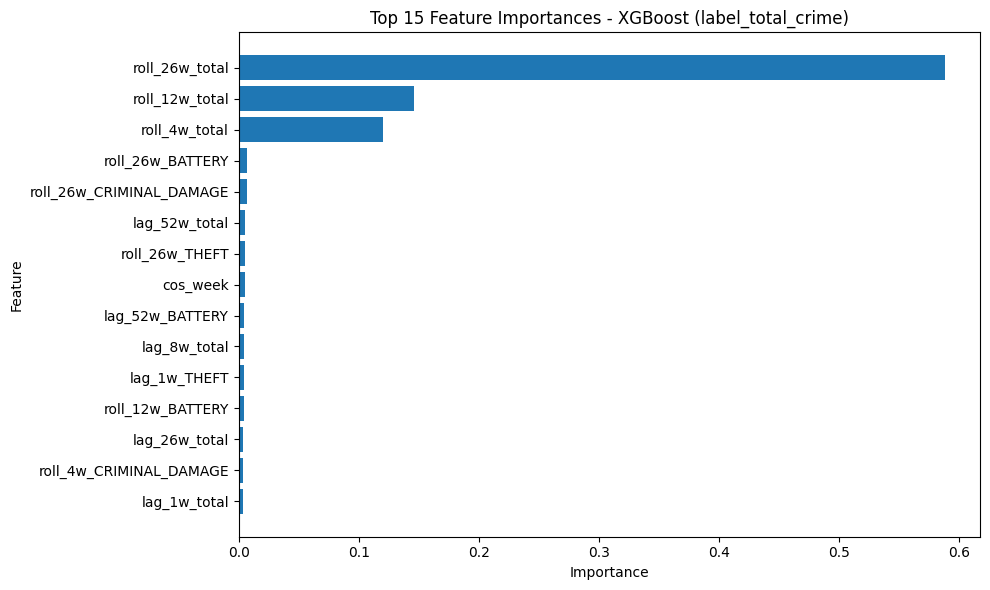

In [13]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost (label_total_crime)")
plt.tight_layout()
plt.show()

In [14]:
# Sort by date

# AI-assisted guidance on my CV approach:
# Here, we assume that the current row order of `train_full` and `train_X` is in one-to-one correspondence.
# First sort by `iso_year` and `iso_week`, then reorder `X` in the same order.
# This way, `TimeSeriesSplit` will actually progress chronologically, rather than jumping around haphazardly.

train_sorted = train_full.copy()
train_sorted["_row_id_for_alignment"] = np.arange(len(train_sorted))

train_sorted = train_sorted.sort_values(
    by=["iso_year", "iso_week", "grid_id"],
    ascending=[True, True, True]
).reset_index(drop=True)

X_train_sorted = train_X.iloc[train_sorted["_row_id_for_alignment"]].reset_index(drop=True)
y_train_sorted = train_sorted[target_col].copy()

print("train_sorted shape:", train_sorted.shape)
print("X_train_sorted shape:", X_train_sorted.shape)

train_sorted shape: (311140, 55)
X_train_sorted shape: (311140, 42)


In [15]:
# Single-fold evaluation function

def evaluate_fold(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [16]:
# Set up time series cross-validation

tscv = TimeSeriesSplit(n_splits=5)
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [17]:
# CV

cv_results = []
fold_num = 1

for train_idx, val_idx in tscv.split(X_train_sorted):
    print(f"\n===== Fold {fold_num} =====")

    X_tr = X_train_sorted.iloc[train_idx]
    X_val = X_train_sorted.iloc[val_idx]
    y_tr = y_train_sorted.iloc[train_idx]
    y_val = y_train_sorted.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    fold_metrics = evaluate_fold(y_val, y_val_pred, y_val_prob)
    fold_metrics["fold"] = fold_num

    cv_results.append(fold_metrics)
    print(fold_metrics)

    fold_num += 1


===== Fold 1 =====
{'accuracy': 0.9122377352668929, 'precision': 0.935746114552766, 'recall': 0.9642729146133859, 'f1': 0.9497953645379431, 'roc_auc': 0.9478246650285642, 'fold': 1}

===== Fold 2 =====
{'accuracy': 0.9036369947547054, 'precision': 0.9286644160543678, 'recall': 0.9597737845480252, 'f1': 0.9439628587128391, 'roc_auc': 0.9417102611810944, 'fold': 2}

===== Fold 3 =====
{'accuracy': 0.902364239432274, 'precision': 0.9289641619007662, 'recall': 0.957965206302942, 'f1': 0.9432418192213267, 'roc_auc': 0.9388151524332117, 'fold': 3}

===== Fold 4 =====
{'accuracy': 0.9128355445850046, 'precision': 0.9389996730957829, 'recall': 0.9615908228624992, 'f1': 0.9501609844308208, 'roc_auc': 0.9444068137659736, 'fold': 4}

===== Fold 5 =====
{'accuracy': 0.9181772601049059, 'precision': 0.941444442056858, 'recall': 0.9665122435473197, 'f1': 0.9538136654076002, 'roc_auc': 0.9473428740873193, 'fold': 5}


In [18]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,accuracy,precision,recall,f1,roc_auc,fold
0,0.912238,0.935746,0.964273,0.949795,0.947825,1
1,0.903637,0.928664,0.959774,0.943963,0.941710,2
2,0.902364,0.928964,0.957965,0.943242,0.938815,3
3,0.912836,0.939000,0.961591,0.950161,0.944407,4
4,0.918177,0.941444,0.966512,0.953814,0.947343,5


In [19]:
cv_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean": [
        cv_results_df["accuracy"].mean(),
        cv_results_df["precision"].mean(),
        cv_results_df["recall"].mean(),
        cv_results_df["f1"].mean(),
        cv_results_df["roc_auc"].mean()
    ],
    "std": [
        cv_results_df["accuracy"].std(),
        cv_results_df["precision"].std(),
        cv_results_df["recall"].std(),
        cv_results_df["f1"].std(),
        cv_results_df["roc_auc"].std()
    ]
})

cv_summary

,metric,mean,std
0,accuracy,0.909850,0.006682
1,precision,0.934764,0.005796
2,recall,0.962023,0.003425
3,f1,0.948195,0.004484
4,roc_auc,0.944020,0.003811


In [20]:
# -------------------------------------------Predicting the top three types of crimes------------------------------------------------------------

In [21]:
# Top 3 crime labels
top3_targets = [
    "label_THEFT",
    "label_BATTERY",
    "label_CRIMINAL_DAMAGE"
]

print(top3_targets)

['label_THEFT', 'label_BATTERY', 'label_CRIMINAL_DAMAGE']


In [22]:
# Unified training and evaluation function (for Top 3)
def run_xgb_for_one_target(target_col, train_full, train_X, test_full, test_X, ext_full, ext_X):
    X_train = train_X.copy()
    X_test = test_X.copy()
    X_ext = ext_X.copy()

    y_train = train_full[target_col].copy()
    y_test = test_full[target_col].copy()
    y_ext = ext_full[target_col].copy()

    print("\n" + "=" * 80)
    print(f"Current target: {target_col}")
    print("=" * 80)

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Chicago 2025
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    test_result = evaluate_binary_classification(
        y_true=y_test,
        y_pred=y_test_pred,
        y_prob=y_test_prob,
        dataset_name=f"Chicago 2025 Test - {target_col}"
    )

    # the generalisation of Texas
    y_ext_pred = model.predict(X_ext)
    y_ext_prob = model.predict_proba(X_ext)[:, 1]

    ext_result = evaluate_binary_classification(
        y_true=y_ext,
        y_pred=y_ext_pred,
        y_prob=y_ext_prob,
        dataset_name=f"Texas External - {target_col}"
    )

    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    return {
        "target": target_col,
        "model": model,
        "test_result": test_result,
        "ext_result": ext_result,
        "feature_importance_df": feature_importance_df
    }

In [23]:
# Complete all three Top 3 tasks in a single go
top3_outputs = []

for target in top3_targets:
    output = run_xgb_for_one_target(
        target_col=target,
        train_full=train_full,
        train_X=train_X,
        test_full=test_full,
        test_X=test_X,
        ext_full=ext_full,
        ext_X=ext_X
    )
    top3_outputs.append(output)


Current target: label_THEFT

===== Chicago 2025 Test - label_THEFT =====
Accuracy : 0.7705
Precision: 0.7745
Recall   : 0.8289
F1-score : 0.8008
ROC-AUC  : 0.8518

Confusion Matrix:
[[10645  4622]
 [ 3278 15879]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7646    0.6973    0.7294     15267
           1     0.7745    0.8289    0.8008     19157

    accuracy                         0.7705     34424
   macro avg     0.7696    0.7631    0.7651     34424
weighted avg     0.7701    0.7705    0.7691     34424


===== Texas External - label_THEFT =====
Accuracy : 0.7737
Precision: 0.8696
Recall   : 0.5824
F1-score : 0.6976
ROC-AUC  : 0.8372

Confusion Matrix:
[[34218  2612]
 [12485 17412]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7327    0.9291    0.8193     36830
           1     0.8696    0.5824    0.6976     29897

    accuracy                         0.7737     66727
   macro av

In [24]:
# Summary: Top 3 types of crimes Results Table
top3_results = []

for output in top3_outputs:
    target = output["target"]

    test_result = output["test_result"].copy()
    test_result["target"] = target
    test_result["split"] = "Chicago2025"

    ext_result = output["ext_result"].copy()
    ext_result["target"] = target
    ext_result["split"] = "TexasExternal"

    top3_results.append(test_result)
    top3_results.append(ext_result)

top3_results_df = pd.DataFrame(top3_results)
top3_results_df

,dataset,accuracy,precision,recall,f1,roc_auc,target,split
0,Chicago 2025 Test - label_THEFT,0.770509,0.774548,0.828888,0.800797,0.851819,label_THEFT,Chicago2025
1,Texas External - label_THEFT,0.773750,0.869557,0.582400,0.697582,0.837197,label_THEFT,TexasExternal
2,Chicago 2025 Test - label_BATTERY,0.765861,0.764464,0.810613,0.786863,0.851964,label_BATTERY,Chicago2025
3,Texas External - label_BATTERY,0.720668,0.859732,0.451392,0.591975,0.804713,label_BATTERY,TexasExternal
4,Chicago 2025 Test - label_CRIMINAL_DAMAGE,0.719934,0.666621,0.666943,0.666782,0.795118,label_CRIMINAL_DAMAGE,Chicago2025
5,Texas External - label_CRIMINAL_DAMAGE,0.775203,0.745196,0.406990,0.526455,0.805629,label_CRIMINAL_DAMAGE,TexasExternal


In [25]:
# Chicago 2025
chicago_results_df = top3_results_df[top3_results_df["split"] == "Chicago2025"].reset_index(drop=True)
chicago_results_df

,dataset,accuracy,precision,recall,f1,roc_auc,target,split
0,Chicago 2025 Test - label_THEFT,0.770509,0.774548,0.828888,0.800797,0.851819,label_THEFT,Chicago2025
1,Chicago 2025 Test - label_BATTERY,0.765861,0.764464,0.810613,0.786863,0.851964,label_BATTERY,Chicago2025
2,Chicago 2025 Test - label_CRIMINAL_DAMAGE,0.719934,0.666621,0.666943,0.666782,0.795118,label_CRIMINAL_DAMAGE,Chicago2025


In [26]:
# Texas 2024
texas_results_df = top3_results_df[top3_results_df["split"] == "TexasExternal"].reset_index(drop=True)
texas_results_df

,dataset,accuracy,precision,recall,f1,roc_auc,target,split
0,Texas External - label_THEFT,0.773750,0.869557,0.582400,0.697582,0.837197,label_THEFT,TexasExternal
1,Texas External - label_BATTERY,0.720668,0.859732,0.451392,0.591975,0.804713,label_BATTERY,TexasExternal
2,Texas External - label_CRIMINAL_DAMAGE,0.775203,0.745196,0.406990,0.526455,0.805629,label_CRIMINAL_DAMAGE,TexasExternal


In [27]:
# CV
def run_timeseries_cv_for_target(train_full, train_X, target_col, n_splits=5):
    # Sort by date
    train_sorted = train_full.copy()
    train_sorted["_row_id_for_alignment"] = np.arange(len(train_sorted))

    train_sorted = train_sorted.sort_values(
        by=["iso_year", "iso_week", "grid_id"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    X_train_sorted = train_X.iloc[train_sorted["_row_id_for_alignment"]].reset_index(drop=True)
    y_train_sorted = train_sorted[target_col].copy()

    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_results = []
    fold_num = 1

    for train_idx, val_idx in tscv.split(X_train_sorted):
        X_tr = X_train_sorted.iloc[train_idx]
        X_val = X_train_sorted.iloc[val_idx]
        y_tr = y_train_sorted.iloc[train_idx]
        y_val = y_train_sorted.iloc[val_idx]

        model = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)

        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        fold_metrics = {
            "target": target_col,
            "fold": fold_num,
            "accuracy": accuracy_score(y_val, y_val_pred),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred, zero_division=0),
            "f1": f1_score(y_val, y_val_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val, y_val_prob)
        }

        cv_results.append(fold_metrics)
        fold_num += 1

    cv_results_df = pd.DataFrame(cv_results)

    cv_summary_df = pd.DataFrame({
        "target": [target_col] * 5,
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "mean": [
            cv_results_df["accuracy"].mean(),
            cv_results_df["precision"].mean(),
            cv_results_df["recall"].mean(),
            cv_results_df["f1"].mean(),
            cv_results_df["roc_auc"].mean()
        ],
        "std": [
            cv_results_df["accuracy"].std(),
            cv_results_df["precision"].std(),
            cv_results_df["recall"].std(),
            cv_results_df["f1"].std(),
            cv_results_df["roc_auc"].std()
        ]
    })

    return cv_results_df, cv_summary_df

In [28]:
top3_cv_all = []
top3_cv_summary_all = []

for target in top3_targets:
    print(f"\nRunning TimeSeriesSplit CV for {target} ...")

    cv_results_df, cv_summary_df = run_timeseries_cv_for_target(
        train_full=train_full,
        train_X=train_X,
        target_col=target,
        n_splits=5
    )

    top3_cv_all.append(cv_results_df)
    top3_cv_summary_all.append(cv_summary_df)


Running TimeSeriesSplit CV for label_THEFT ...

Running TimeSeriesSplit CV for label_BATTERY ...

Running TimeSeriesSplit CV for label_CRIMINAL_DAMAGE ...


In [29]:
top3_cv_results_df = pd.concat(top3_cv_all, ignore_index=True)
top3_cv_summary_df = pd.concat(top3_cv_summary_all, ignore_index=True)

print("Detailed CV results:")
display(top3_cv_results_df)

print("\nCV summary:")
display(top3_cv_summary_df)

Detailed CV results:


,target,fold,accuracy,precision,recall,f1,roc_auc
0,label_THEFT,1,0.782745,0.804569,0.844061,0.823842,0.860157
1,label_THEFT,2,0.771830,0.773062,0.839768,0.805036,0.851831
2,label_THEFT,3,0.746471,0.731957,0.788053,0.758970,0.829384
3,label_THEFT,4,0.765003,0.785142,0.811793,0.798245,0.842466
4,label_THEFT,5,0.774202,0.789517,0.845490,0.816545,0.852528
5,label_BATTERY,1,0.781626,0.797770,0.815519,0.806546,0.865614
6,label_BATTERY,2,0.779216,0.779485,0.821270,0.799832,0.862592
7,label_BATTERY,3,0.769631,0.769148,0.783911,0.776460,0.856440
8,label_BATTERY,4,0.764212,0.761421,0.804590,0.782411,0.849389
9,label_BATTERY,5,0.772370,0.772488,0.828156,0.799354,0.857202



CV summary:


,target,metric,mean,std
0,label_THEFT,accuracy,0.768050,0.013629
1,label_THEFT,precision,0.776849,0.027510
2,label_THEFT,recall,0.825833,0.025186
3,label_THEFT,f1,0.800528,0.025262
4,label_THEFT,roc_auc,0.847273,0.011806
5,label_BATTERY,accuracy,0.773411,0.007092
6,label_BATTERY,precision,0.776063,0.013765
7,label_BATTERY,recall,0.810689,0.017282
8,label_BATTERY,f1,0.792921,0.012809
9,label_BATTERY,roc_auc,0.858247,0.006244


In [30]:
importance_dict = {}

for output in top3_outputs:
    importance_dict[output["target"]] = output["feature_importance_df"]

for k, v in importance_dict.items():
    print(f"\n{k}")
    display(v.head(10))


label_THEFT


,feature,importance
0,roll_26w_total,0.347735
1,roll_12w_total,0.230234
2,roll_12w_THEFT,0.222698
3,roll_26w_THEFT,0.036794
4,roll_4w_total,0.025178
5,roll_4w_THEFT,0.021099
6,cos_week,0.005987
7,lag_1w_THEFT,0.005772
8,lag_52w_THEFT,0.005523
9,roll_26w_BATTERY,0.004786



label_BATTERY


,feature,importance
0,roll_26w_total,0.500398
1,roll_12w_BATTERY,0.166519
2,roll_4w_total,0.080778
3,roll_26w_BATTERY,0.054197
4,roll_12w_total,0.045642
5,roll_4w_BATTERY,0.023034
6,roll_26w_THEFT,0.008208
7,roll_12w_THEFT,0.006846
8,cos_week,0.006287
9,lag_52w_BATTERY,0.005924



label_CRIMINAL_DAMAGE


,feature,importance
0,roll_26w_total,0.390942
1,roll_4w_total,0.199914
2,roll_12w_total,0.160820
3,roll_26w_CRIMINAL_DAMAGE,0.036123
4,roll_12w_CRIMINAL_DAMAGE,0.027657
5,roll_12w_BATTERY,0.019567
6,roll_26w_THEFT,0.009030
7,roll_4w_BATTERY,0.008970
8,roll_26w_BATTERY,0.008907
9,cos_week,0.007812


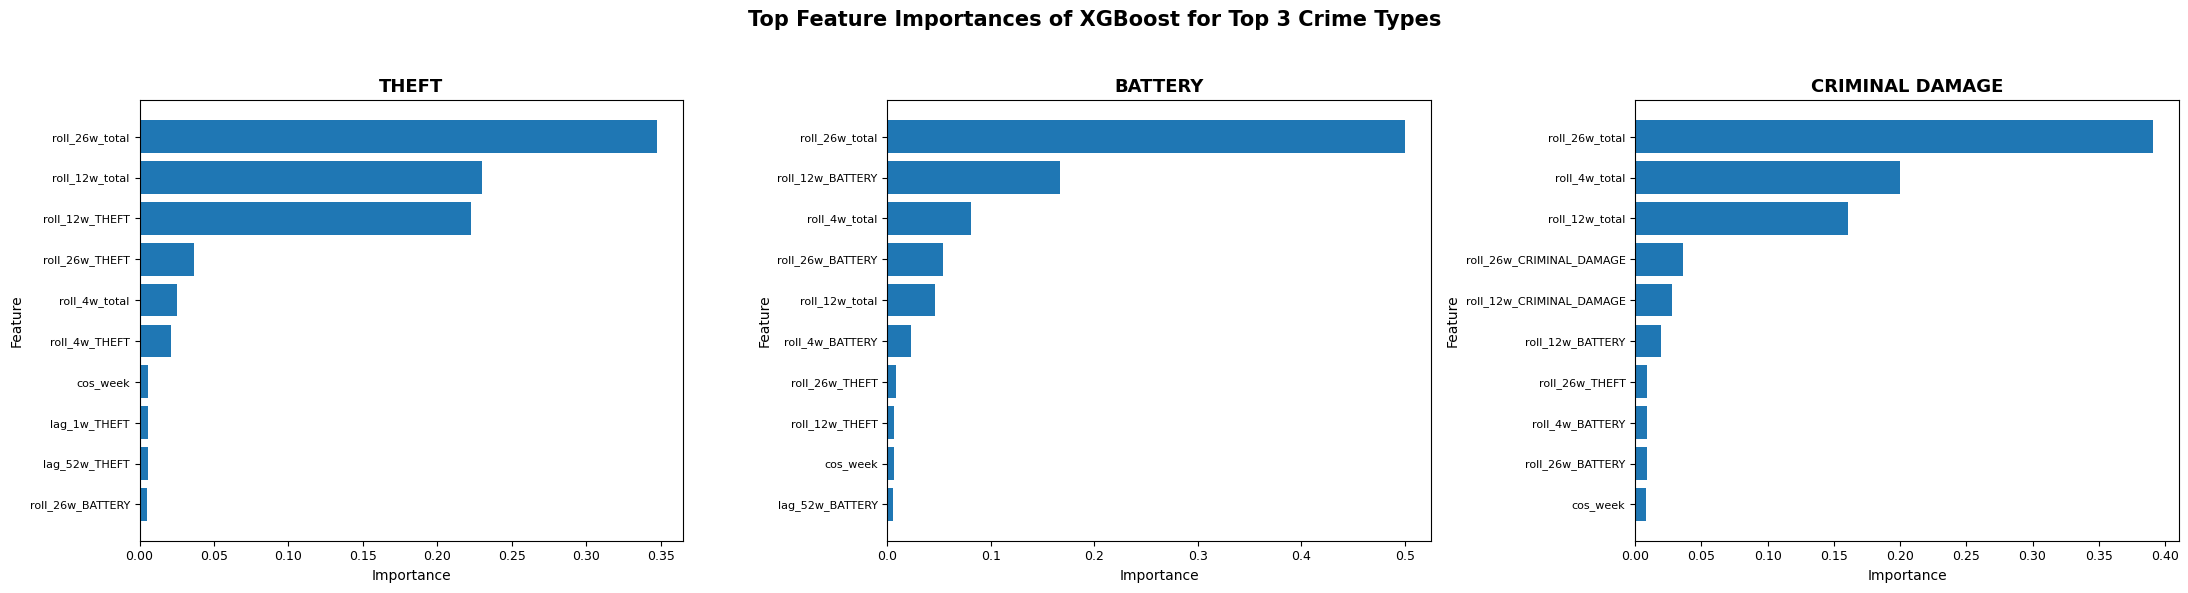

In [31]:
top_n = 10

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

target_display_names = {
    "label_THEFT": "THEFT",
    "label_BATTERY": "BATTERY",
    "label_CRIMINAL_DAMAGE": "CRIMINAL DAMAGE"
}

for ax, target in zip(axes, top3_targets):
    df_imp = importance_dict[target].head(top_n).copy()

    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1])
    ax.set_title(target_display_names[target], fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("Top Feature Importances of XGBoost for Top 3 Crime Types", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [32]:
# Chicago 2025: Top 3 crime occurrence prediction (0/1)

chicago_top3_pred_df = test_full[["grid_id", "iso_year", "iso_week", "year_week"]].copy()

target_name_map = {
    "label_THEFT": "THEFT",
    "label_BATTERY": "BATTERY",
    "label_CRIMINAL_DAMAGE": "CRIMINAL_DAMAGE"
}

for output in top3_outputs:
    target = output["target"]
    model = output["model"]

    pred = model.predict(test_X)
    prob = model.predict_proba(test_X)[:, 1]

    chicago_top3_pred_df[f"pred_{target_name_map[target]}"] = pred
    chicago_top3_pred_df[f"prob_{target_name_map[target]}"] = prob

chicago_top3_pred_df.head()

,grid_id,iso_year,iso_week,year_week,pred_THEFT,prob_THEFT,pred_BATTERY,prob_BATTERY,pred_CRIMINAL_DAMAGE,prob_CRIMINAL_DAMAGE
0,41.640_-87.540,2025,1,2025-W01,0,0.128446,0,0.091162,0,0.038574
1,41.640_-87.540,2025,2,2025-W02,0,0.092981,0,0.097360,0,0.039922
2,41.640_-87.540,2025,3,2025-W03,0,0.091400,0,0.102838,0,0.038408
3,41.640_-87.540,2025,4,2025-W04,0,0.091056,0,0.070849,0,0.038452
4,41.640_-87.540,2025,5,2025-W05,0,0.083547,0,0.072238,0,0.045979


In [33]:
# Texas external: Top 3 crime occurrence prediction (0/1)

texas_top3_pred_df = ext_full[["agency_id", "iso_year", "iso_week", "year_week"]].copy()

for output in top3_outputs:
    target = output["target"]
    model = output["model"]

    pred = model.predict(ext_X)
    prob = model.predict_proba(ext_X)[:, 1]

    texas_top3_pred_df[f"pred_{target_name_map[target]}"] = pred
    texas_top3_pred_df[f"prob_{target_name_map[target]}"] = prob

texas_top3_pred_df.head()

,agency_id,iso_year,iso_week,year_week,pred_THEFT,prob_THEFT,pred_BATTERY,prob_BATTERY,pred_CRIMINAL_DAMAGE,prob_CRIMINAL_DAMAGE
0,18753,2024,1,2024-W01,0,0.021458,0,0.014053,0,0.008906
1,18753,2024,2,2024-W02,0,0.065752,0,0.022642,0,0.018316
2,18753,2024,3,2024-W03,0,0.037753,0,0.024344,0,0.029088
3,18753,2024,4,2024-W04,0,0.064960,0,0.023752,0,0.035074
4,18753,2024,5,2024-W05,0,0.207993,0,0.122805,0,0.120043


In [34]:
#---------------------- TOTAL_CRIME spatial accuracy evaluation (Chicago 2025)--------------------------------------------------------------------

In [35]:
# Chicago 2025 prediction table for spatial/temporal evaluation

chicago_eval_df = test_full[["grid_id", "iso_year", "iso_week", "year_week"]].copy()
chicago_eval_df["y_true"] = y_test.values
chicago_eval_df["y_pred"] = y_test_pred
chicago_eval_df["y_prob"] = y_test_prob

chicago_eval_df.head()

,grid_id,iso_year,iso_week,year_week,y_true,y_pred,y_prob
0,41.640_-87.540,2025,1,2025-W01,0,0,0.372326
1,41.640_-87.540,2025,2,2025-W02,0,0,0.348570
2,41.640_-87.540,2025,3,2025-W03,0,0,0.320154
3,41.640_-87.540,2025,4,2025-W04,0,0,0.294817
4,41.640_-87.540,2025,5,2025-W05,1,0,0.318455


In [36]:
# Detect Texas spatial unit column automatically
def get_texas_spatial_unit_col(df):
    if "grid_id" in df.columns:
        return "grid_id"
    elif "agency_id" in df.columns:
        return "agency_id"
    else:
        raise ValueError("Texas external dataset has neither 'grid_id' nor 'agency_id'. Please check the spatial unit column.")

In [37]:
# Group-level evaluation function

def safe_group_metrics(df):
    y_true = df["y_true"]
    y_pred = df["y_pred"]
    y_prob = df["y_prob"]

    result = {
        "n_samples": len(df),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred)
    }

    result["precision"] = precision_score(y_true, y_pred, zero_division=0)
    result["recall"] = recall_score(y_true, y_pred, zero_division=0)
    result["f1"] = f1_score(y_true, y_pred, zero_division=0)

    # The AUC is only meaningful when both 0 and 1 are present within the group
    if y_true.nunique() == 2:
        result["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        result["roc_auc"] = np.nan

    return pd.Series(result)

In [38]:
# Spatial evaluation by grid_id

spatial_eval_df = (
    chicago_eval_df
    .groupby("grid_id")
    .apply(safe_group_metrics)
    .reset_index()
)

spatial_eval_df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3654757117.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)


,grid_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,41.640_-87.540,52.0,0.346154,0.653846,0.000000,0.000000,0.000000,0.374183
1,41.640_-87.550,52.0,0.538462,0.557692,0.560976,0.821429,0.666667,0.455357
2,41.640_-87.620,52.0,0.403846,0.557692,0.428571,0.285714,0.342857,0.402458
3,41.650_-87.530,52.0,0.596154,0.615385,0.612245,0.967742,0.750000,0.473118
4,41.650_-87.540,52.0,0.461538,0.538462,0.500000,0.875000,0.636364,0.507440


In [39]:
# Best / worst spatial units

spatial_eval_filtered = spatial_eval_df[spatial_eval_df["n_samples"] >= 10].copy()

print("Top 10 grids by F1:")
display(spatial_eval_filtered.sort_values("f1", ascending=False).head(10))

print("Bottom 10 grids by F1:")
display(spatial_eval_filtered.sort_values("f1", ascending=True).head(10))

Top 10 grids by F1:


,grid_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
252,41.790_-87.640,52.0,1.0,1.0,1.0,1.0,1.0,NaN
299,41.810_-87.710,52.0,1.0,1.0,1.0,1.0,1.0,NaN
344,41.840_-87.730,52.0,1.0,1.0,1.0,1.0,1.0,NaN
343,41.840_-87.720,52.0,1.0,1.0,1.0,1.0,1.0,NaN
342,41.840_-87.710,52.0,1.0,1.0,1.0,1.0,1.0,NaN
341,41.840_-87.700,52.0,1.0,1.0,1.0,1.0,1.0,NaN
334,41.840_-87.630,52.0,1.0,1.0,1.0,1.0,1.0,NaN
333,41.840_-87.620,52.0,1.0,1.0,1.0,1.0,1.0,NaN
527,41.950_-87.650,52.0,1.0,1.0,1.0,1.0,1.0,NaN
528,41.950_-87.660,52.0,1.0,1.0,1.0,1.0,1.0,NaN


Bottom 10 grids by F1:


,grid_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,41.640_-87.540,52.0,0.346154,0.653846,0.0,0.0,0.0,0.374183
635,41.990_-87.830,52.0,0.115385,0.884615,0.0,0.0,0.0,0.492754
590,41.970_-87.870,52.0,0.038462,0.961538,0.0,0.0,0.0,0.520000
40,41.680_-87.700,52.0,0.153846,0.846154,0.0,0.0,0.0,0.406250
81,41.700_-87.720,52.0,0.307692,0.692308,0.0,0.0,0.0,0.338542
42,41.680_-87.720,52.0,0.346154,0.653846,0.0,0.0,0.0,0.352124
129,41.730_-87.690,52.0,0.269231,0.730769,0.0,0.0,0.0,0.413534
98,41.710_-87.700,52.0,0.057692,0.942308,0.0,0.0,0.0,0.476190
197,41.760_-87.750,52.0,0.134615,0.865385,0.0,0.0,0.0,0.349206
47,41.690_-87.560,52.0,0.096154,0.903846,0.0,0.0,0.0,0.242553


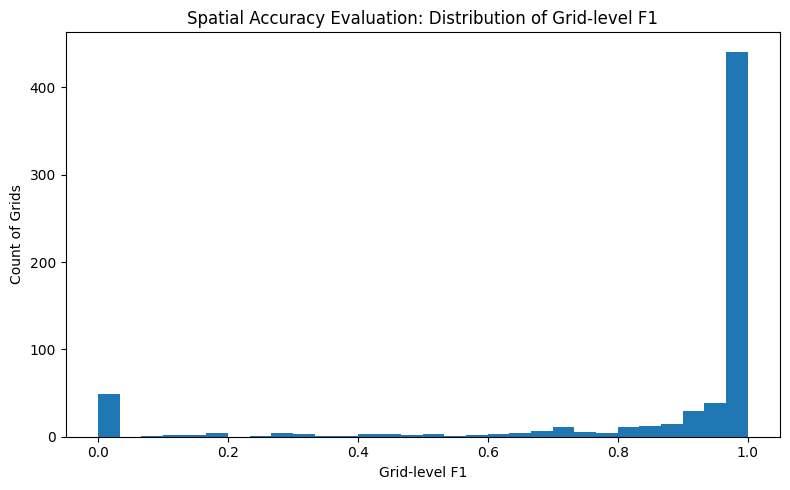

In [40]:
# Distribution of spatial F1

plt.figure(figsize=(8, 5))
plt.hist(spatial_eval_filtered["f1"].dropna(), bins=30)
plt.xlabel("Grid-level F1")
plt.ylabel("Count of Grids")
plt.title("Spatial Accuracy Evaluation: Distribution of Grid-level F1")
plt.tight_layout()
plt.show()

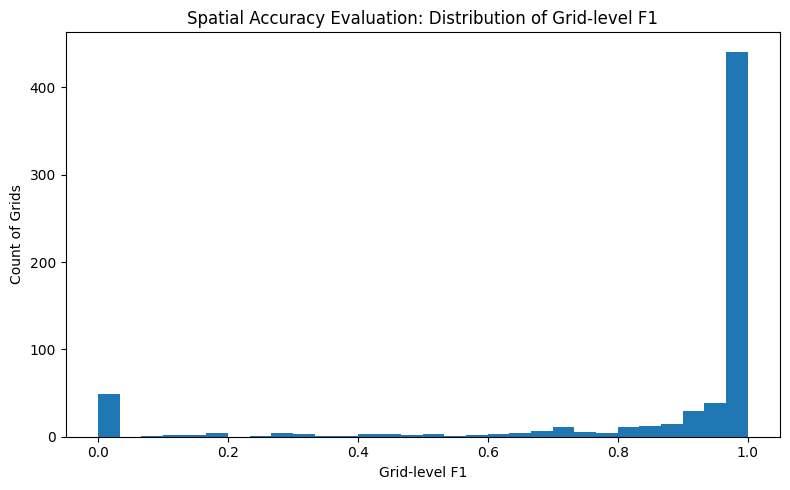

In [41]:
# Distribution of spatial F1

plt.figure(figsize=(8, 5))
plt.hist(spatial_eval_filtered["f1"].dropna(), bins=30)
plt.xlabel("Grid-level F1")
plt.ylabel("Count of Grids")
plt.title("Spatial Accuracy Evaluation: Distribution of Grid-level F1")
plt.tight_layout()
plt.show()

In [42]:
# High-risk vs low-risk spatial comparison

train_grid_risk = (
    train_full.groupby("grid_id")["label_total_crime"]
    .mean()
    .reset_index()
    .rename(columns={"label_total_crime": "historical_risk"})
)

spatial_eval_with_risk = spatial_eval_filtered.merge(train_grid_risk, on="grid_id", how="left")

# AI-assisted guidance:
# As there are a large number of duplicate values in `historical_risk` (particularly as many grid values are close to 1.0),
# Using qcut directly often results in errors regarding duplicate partition boundaries.
# Here, we first use `rank(method="first")` to break the ties, then group by tertiles, which yields more stable results.
spatial_eval_with_risk["risk_group"] = pd.qcut(
    spatial_eval_with_risk["historical_risk"].rank(method="first"),
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_group_summary = (
    spatial_eval_with_risk
    .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
    .mean()
    .reset_index()
)

risk_group_summary

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3153050769.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.748695,0.562998,0.658414,0.593561,0.485185
1,Medium Risk,0.981294,0.981294,1.000000,0.990350,0.507595
2,High Risk,0.999478,0.999478,1.000000,0.999736,0.242627


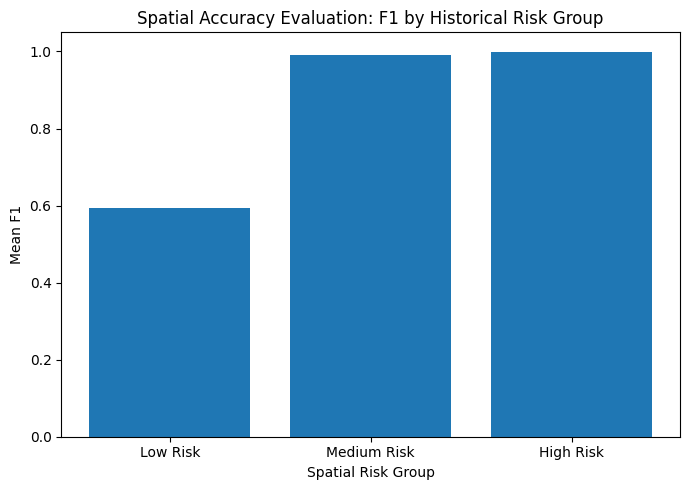

In [43]:
# Spatial comparison plot by risk group

plt.figure(figsize=(7, 5))
plt.bar(risk_group_summary["risk_group"], risk_group_summary["f1"])
plt.xlabel("Spatial Risk Group")
plt.ylabel("Mean F1")
plt.title("Spatial Accuracy Evaluation: F1 by Historical Risk Group")
plt.tight_layout()
plt.show()

In [44]:
# Temporal evaluation by iso_week

temporal_eval_df = (
    chicago_eval_df
    .groupby("iso_week")
    .apply(safe_group_metrics)
    .reset_index()
)

temporal_eval_df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3883120708.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)


,iso_week,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,1,662.0,0.876133,0.909366,0.943686,0.953448,0.948542,0.937973
1,2,662.0,0.842900,0.913897,0.925297,0.976703,0.950305,0.947322
2,3,662.0,0.835347,0.886707,0.905085,0.965642,0.934383,0.938451
3,4,662.0,0.845921,0.906344,0.923469,0.969643,0.945993,0.940196
4,5,662.0,0.862538,0.909366,0.939759,0.956217,0.947917,0.939108


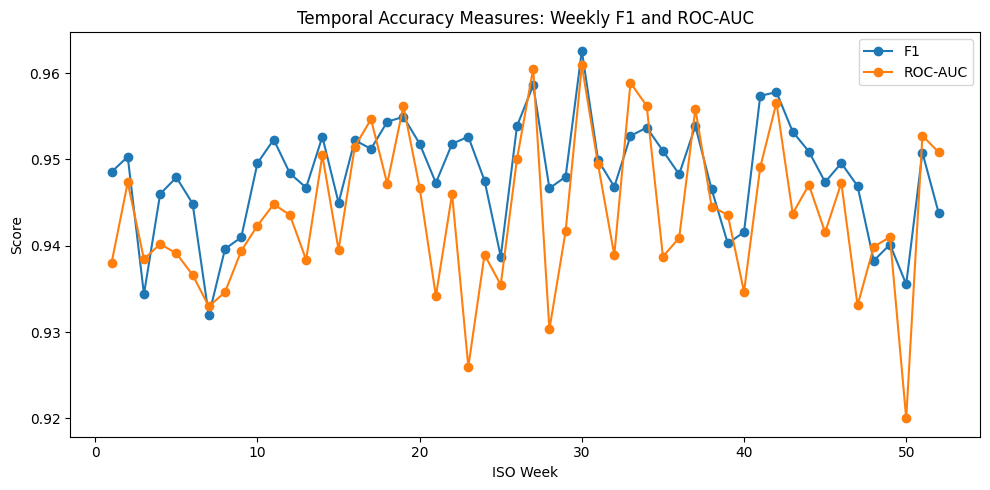

In [45]:
# Weekly temporal performance curves


plt.figure(figsize=(10, 5))
plt.plot(temporal_eval_df["iso_week"], temporal_eval_df["f1"], marker="o", label="F1")
plt.plot(temporal_eval_df["iso_week"], temporal_eval_df["roc_auc"], marker="o", label="ROC-AUC")
plt.xlabel("ISO Week")
plt.ylabel("Score")
plt.title("Temporal Accuracy Measures: Weekly F1 and ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Best / worst weeks

print("Top 10 weeks by F1:")
display(temporal_eval_df.sort_values("f1", ascending=False).head(10))

print("Bottom 10 weeks by F1:")
display(temporal_eval_df.sort_values("f1", ascending=True).head(10))

Top 10 weeks by F1:


,iso_week,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
29,30,662.0,0.874622,0.933535,0.948074,0.977547,0.962585,0.960880
26,27,662.0,0.888218,0.925982,0.952941,0.964286,0.958580,0.960517
41,42,662.0,0.868580,0.925982,0.948805,0.966957,0.957795,0.956562
40,41,662.0,0.854985,0.925982,0.943396,0.971731,0.957354,0.949085
18,19,662.0,0.858006,0.921450,0.940273,0.970070,0.954939,0.956192
17,18,662.0,0.873112,0.919940,0.950257,0.958478,0.954350,0.947191
36,37,662.0,0.874622,0.918429,0.944162,0.963731,0.953846,0.955855
25,26,662.0,0.873112,0.918429,0.942568,0.965398,0.953846,0.950033
33,34,662.0,0.870091,0.918429,0.942373,0.965278,0.953688,0.956193
42,43,662.0,0.861027,0.918429,0.941781,0.964912,0.953206,0.943726


Bottom 10 weeks by F1:


,iso_week,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
6,7,662.0,0.821752,0.883686,0.897785,0.968750,0.931919,0.932975
2,3,662.0,0.835347,0.886707,0.905085,0.965642,0.934383,0.938451
49,50,662.0,0.854985,0.888218,0.922680,0.948763,0.935540,0.920007
47,48,662.0,0.829305,0.894260,0.909402,0.969035,0.938272,0.939899
24,25,662.0,0.856495,0.892749,0.918919,0.959436,0.938740,0.935468
7,8,662.0,0.839879,0.895770,0.914821,0.965827,0.939633,0.934624
48,49,662.0,0.838369,0.897281,0.919105,0.962162,0.940141,0.940987
38,39,662.0,0.861027,0.895770,0.928205,0.952632,0.940260,0.943574
8,9,662.0,0.859517,0.897281,0.929674,0.952548,0.940972,0.939405
39,40,662.0,0.873112,0.897281,0.935154,0.948097,0.941581,0.934647


In [47]:
# Quarter-level temporal evaluation

# Start by constructing a rough quarter from iso_week
chicago_eval_df["quarter"] = pd.cut(
    chicago_eval_df["iso_week"],
    bins=[0, 13, 26, 39, 53],
    labels=["Q1", "Q2", "Q3", "Q4"]
)

quarter_eval_df = (
    chicago_eval_df
    .groupby("quarter")
    .apply(safe_group_metrics)
    .reset_index()
)

quarter_eval_df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\697248168.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quarter")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\697248168.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.849988,0.904253,0.926983,0.963226,0.944757,0.938860
1,Q2,8606.0,0.865675,0.912968,0.939410,0.961477,0.950315,0.944207
2,Q3,8606.0,0.868231,0.913200,0.937655,0.964133,0.950709,0.947207
3,Q4,8606.0,0.853823,0.908436,0.932946,0.961894,0.947199,0.942630


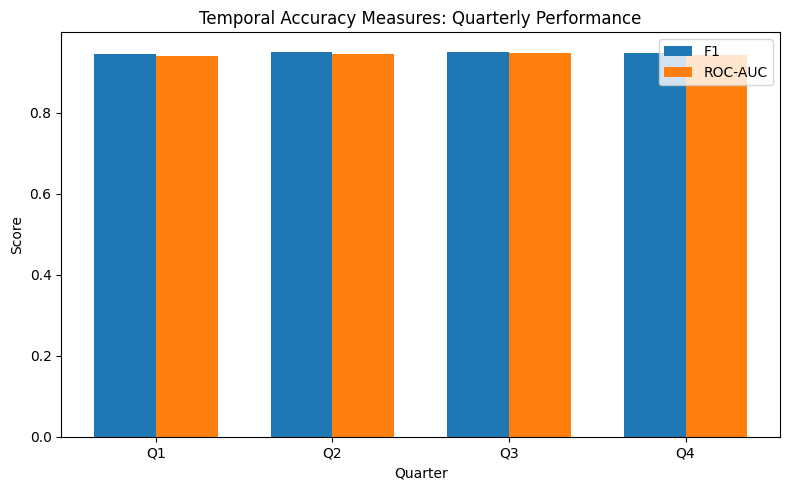

In [48]:
# Quarter-level temporal plot

x = np.arange(len(quarter_eval_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, quarter_eval_df["f1"], width, label="F1")
plt.bar(x + width/2, quarter_eval_df["roc_auc"], width, label="ROC-AUC")

plt.xticks(x, quarter_eval_df["quarter"])
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.title("Temporal Accuracy Measures: Quarterly Performance")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Hotspot / Top-k spatial evaluation
def compute_hotspot_metrics(eval_df, k_list=[5, 10, 20]):
    """
    eval_df must contain:
    grid_id, y_true, y_prob, y_pred
    """

    grid_summary = (
        eval_df.groupby("grid_id")
        .agg(
            true_count=("y_true", "sum"),
            pred_count=("y_pred", "sum"),
            pred_score=("y_prob", "sum"),
            n_samples=("y_true", "size")
        )
        .reset_index()
    )

    results = []

    total_true_events = grid_summary["true_count"].sum()

    for k in k_list:
        true_topk = set(
            grid_summary.sort_values("true_count", ascending=False)
            .head(k)["grid_id"]
        )

        pred_topk_df = (
            grid_summary.sort_values("pred_score", ascending=False)
            .head(k)
        )
        pred_topk = set(pred_topk_df["grid_id"])

        hit_count = len(true_topk & pred_topk)
        hit_rate = hit_count / k if k > 0 else np.nan

        covered_true_events = pred_topk_df["true_count"].sum()
        coverage = (
            covered_true_events / total_true_events
            if total_true_events > 0 else np.nan
        )

        results.append({
            "k": k,
            "hit_count": hit_count,
            "hit_rate": hit_rate,
            "coverage": coverage
        })

    hotspot_metrics_df = pd.DataFrame(results)
    return grid_summary, hotspot_metrics_df

In [50]:
# Spatial error analysis by grid
def compute_spatial_error_by_grid(eval_df):
    error_df = eval_df.copy()

    error_df["tp"] = ((error_df["y_true"] == 1) & (error_df["y_pred"] == 1)).astype(int)
    error_df["tn"] = ((error_df["y_true"] == 0) & (error_df["y_pred"] == 0)).astype(int)
    error_df["fp"] = ((error_df["y_true"] == 0) & (error_df["y_pred"] == 1)).astype(int)
    error_df["fn"] = ((error_df["y_true"] == 1) & (error_df["y_pred"] == 0)).astype(int)

    spatial_error_df = (
        error_df.groupby("grid_id")
        .agg(
            n_samples=("y_true", "size"),
            true_count=("y_true", "sum"),
            pred_count=("y_pred", "sum"),
            tp_count=("tp", "sum"),
            tn_count=("tn", "sum"),
            fp_count=("fp", "sum"),
            fn_count=("fn", "sum")
        )
        .reset_index()
    )

    spatial_error_df["fp_rate"] = spatial_error_df["fp_count"] / spatial_error_df["n_samples"]
    spatial_error_df["fn_rate"] = spatial_error_df["fn_count"] / spatial_error_df["n_samples"]

    return spatial_error_df

In [51]:
# TOTAL_CRIME hotspot metrics
total_grid_summary, total_hotspot_metrics_df = compute_hotspot_metrics(
    chicago_eval_df,
    k_list=[5, 10, 20]
)

print("TOTAL_CRIME hotspot metrics")
display(total_hotspot_metrics_df)

TOTAL_CRIME hotspot metrics


,k,hit_count,hit_rate,coverage
0,5,0,0.0,0.008788
1,10,0,0.0,0.017576
2,20,0,0.0,0.035153


In [52]:
# TOTAL_CRIME spatial error by grid
total_spatial_error_df = compute_spatial_error_by_grid(chicago_eval_df)

print("Top 10 grids with highest FN count:")
display(total_spatial_error_df.sort_values("fn_count", ascending=False).head(10))

print("Top 10 grids with highest FP count:")
display(total_spatial_error_df.sort_values("fp_count", ascending=False).head(10))

Top 10 grids with highest FN count:


,grid_id,n_samples,true_count,pred_count,tp_count,tn_count,fp_count,fn_count,fp_rate,fn_rate
310,41.820_-87.660,52,24,11,3,20,8,21,0.153846,0.403846
446,41.900_-87.800,52,22,3,2,29,1,20,0.019231,0.384615
377,41.870_-87.620,52,19,0,0,33,0,19,0.000000,0.365385
544,41.950_-87.820,52,20,2,1,31,1,19,0.019231,0.365385
0,41.640_-87.540,52,18,0,0,34,0,18,0.000000,0.346154
269,41.790_-87.810,52,18,0,0,34,0,18,0.000000,0.346154
82,41.700_-87.730,52,18,1,0,33,1,18,0.019231,0.346154
604,41.980_-87.740,52,20,6,2,28,4,18,0.076923,0.346154
42,41.680_-87.720,52,18,0,0,34,0,18,0.000000,0.346154
304,41.810_-87.760,52,20,4,2,30,2,18,0.038462,0.346154


Top 10 grids with highest FP count:


,grid_id,n_samples,true_count,pred_count,tp_count,tn_count,fp_count,fn_count,fp_rate,fn_rate
628,41.990_-87.760,52,26,50,25,1,25,1,0.480769,0.019231
10,41.650_-87.640,52,23,38,14,5,24,9,0.461538,0.173077
132,41.730_-87.720,52,28,52,28,0,24,0,0.461538,0.000000
634,41.990_-87.820,52,28,50,27,1,23,1,0.442308,0.019231
97,41.710_-87.690,52,29,52,29,0,23,0,0.442308,0.000000
658,42.010_-87.810,52,27,41,18,2,23,9,0.442308,0.173077
466,41.910_-87.810,52,30,52,30,0,22,0,0.423077,0.000000
130,41.730_-87.700,52,28,50,28,2,22,0,0.423077,0.000000
567,41.960_-87.840,52,27,47,25,3,22,2,0.423077,0.038462
114,41.720_-87.690,52,29,51,29,1,22,0,0.423077,0.000000


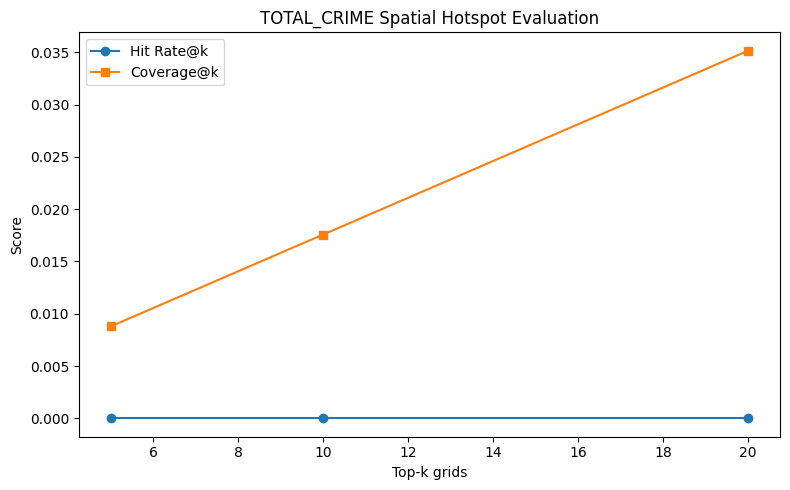

In [53]:
# Plot TOTAL_CRIME hotspot hit rate / coverage
plt.figure(figsize=(8, 5))
plt.plot(total_hotspot_metrics_df["k"], total_hotspot_metrics_df["hit_rate"], marker="o", label="Hit Rate@k")
plt.plot(total_hotspot_metrics_df["k"], total_hotspot_metrics_df["coverage"], marker="s", label="Coverage@k")
plt.xlabel("Top-k grids")
plt.ylabel("Score")
plt.title("TOTAL_CRIME Spatial Hotspot Evaluation")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
#---------------------- Top_3_CRIME spatial accuracy evaluation (Chicago 2025)--------------------------------------------------------------------

In [55]:
# Build Chicago 2025 evaluation table for one Top 3 target

def build_chicago_eval_df_for_target(target_col, model, test_full, test_X):
    eval_df = test_full[["grid_id", "iso_year", "iso_week", "year_week"]].copy()
    eval_df["target"] = target_col
    eval_df["y_true"] = test_full[target_col].values
    eval_df["y_pred"] = model.predict(test_X)
    eval_df["y_prob"] = model.predict_proba(test_X)[:, 1]
    return eval_df

In [56]:
# Spatial evaluation for one target

def run_spatial_evaluation_for_target(target_col, model, train_full, test_full, test_X):
    # Building the Chicago 2025 Forecast Table
    chicago_eval_df = build_chicago_eval_df_for_target(
        target_col=target_col,
        model=model,
        test_full=test_full,
        test_X=test_X
    )

    # grid-level
    spatial_eval_df = (
        chicago_eval_df
        .groupby("grid_id")
        .apply(safe_group_metrics)
        .reset_index()
    )

    # Grid with too few samples
    spatial_eval_filtered = spatial_eval_df[spatial_eval_df["n_samples"] >= 10].copy()

    # Historical risk grouping
    train_grid_risk = (
        train_full.groupby("grid_id")[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: "historical_risk"})
    )

    spatial_eval_with_risk = spatial_eval_filtered.merge(train_grid_risk, on="grid_id", how="left")

    # Use `rank` to eliminate duplicate values and prevent `qcut` from returning an error
    spatial_eval_with_risk["risk_group"] = pd.qcut(
        spatial_eval_with_risk["historical_risk"].rank(method="first"),
        q=3,
        labels=["Low Risk", "Medium Risk", "High Risk"]
    )

    risk_group_summary = (
        spatial_eval_with_risk
        .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
        .mean()
        .reset_index()
    )

    return chicago_eval_df, spatial_eval_df, spatial_eval_with_risk, risk_group_summary

In [57]:
# Temporal evaluation for one target

def run_temporal_evaluation_for_target(target_col, model, test_full, test_X):
    chicago_eval_df = build_chicago_eval_df_for_target(
        target_col=target_col,
        model=model,
        test_full=test_full,
        test_X=test_X
    )

    # weekly
    temporal_eval_df = (
        chicago_eval_df
        .groupby("iso_week")
        .apply(safe_group_metrics)
        .reset_index()
    )

    # quarter
    chicago_eval_df = chicago_eval_df.copy()
    chicago_eval_df["quarter"] = pd.cut(
        chicago_eval_df["iso_week"],
        bins=[0, 13, 26, 39, 53],
        labels=["Q1", "Q2", "Q3", "Q4"]
    )

    quarter_eval_df = (
        chicago_eval_df
        .groupby("quarter")
        .apply(safe_group_metrics)
        .reset_index()
    )

    return temporal_eval_df, quarter_eval_df

In [58]:
# Run spatial + temporal evaluation for all Top 3 targets

top3_spatial_outputs = {}
top3_temporal_outputs = {}

for output in top3_outputs:
    target = output["target"]
    model = output["model"]

    print(f"\nRunning spatial evaluation for {target} ...")
    chicago_eval_df, spatial_eval_df, spatial_eval_with_risk, risk_group_summary = run_spatial_evaluation_for_target(
        target_col=target,
        model=model,
        train_full=train_full,
        test_full=test_full,
        test_X=test_X
    )

    top3_spatial_outputs[target] = {
        "chicago_eval_df": chicago_eval_df,
        "spatial_eval_df": spatial_eval_df,
        "spatial_eval_with_risk": spatial_eval_with_risk,
        "risk_group_summary": risk_group_summary
    }

    print(f"Running temporal evaluation for {target} ...")
    temporal_eval_df, quarter_eval_df = run_temporal_evaluation_for_target(
        target_col=target,
        model=model,
        test_full=test_full,
        test_X=test_X
    )

    top3_temporal_outputs[target] = {
        "temporal_eval_df": temporal_eval_df,
        "quarter_eval_df": quarter_eval_df
    }


Running spatial evaluation for label_THEFT ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3090908658.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3090908658.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


Running temporal evaluation for label_THEFT ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quarter")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded


Running spatial evaluation for label_BATTERY ...


...

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quarter")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded


Running spatial evaluation for label_CRIMINAL_DAMAGE ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3090908658.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3090908658.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


Running temporal evaluation for label_CRIMINAL_DAMAGE ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quarter")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\1182706719.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded

In [59]:
# View spatial risk-group summaries

for target in top3_spatial_outputs:
    print("\n" + "=" * 80)
    print(f"Spatial risk-group summary - {target}")
    print("=" * 80)
    display(top3_spatial_outputs[target]["risk_group_summary"])


Spatial risk-group summary - label_THEFT


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.801775,0.048618,0.028373,0.031342,0.472872
1,Medium Risk,0.626399,0.568252,0.760535,0.635020,0.488895
2,High Risk,0.882701,0.882727,0.999878,0.934393,0.511218



Spatial risk-group summary - label_BATTERY


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.829621,0.030910,0.015056,0.018266,0.444191
1,Medium Risk,0.592308,0.499528,0.682946,0.564378,0.473561
2,High Risk,0.874869,0.875097,0.998729,0.929937,0.516571



Spatial risk-group summary - label_CRIMINAL_DAMAGE


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.868430,0.000000,0.000000,0.000000,0.467563
1,Medium Risk,0.591259,0.321917,0.293825,0.274683,0.493661
2,High Risk,0.699530,0.701250,0.971039,0.808430,0.521545


In [60]:
# View quarterly temporal summaries

for target in top3_temporal_outputs:
    print("\n" + "=" * 80)
    print(f"Quarterly temporal summary - {target}")
    print("=" * 80)
    display(top3_temporal_outputs[target]["quarter_eval_df"])


Quarterly temporal summary - label_THEFT


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.546363,0.769347,0.774278,0.815610,0.794407,0.849647
1,Q2,8606.0,0.566117,0.774343,0.784466,0.829228,0.806226,0.853397
2,Q3,8606.0,0.577620,0.772020,0.780115,0.842889,0.810288,0.854539
3,Q4,8606.0,0.535905,0.766326,0.758703,0.826973,0.791368,0.849088



Quarterly temporal summary - label_BATTERY


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.509644,0.754241,0.743617,0.790242,0.766221,0.839222
1,Q2,8606.0,0.549152,0.773879,0.776232,0.826492,0.800574,0.858430
2,Q3,8606.0,0.552057,0.770044,0.773157,0.825721,0.798575,0.857255
3,Q4,8606.0,0.521845,0.765280,0.763152,0.797818,0.780100,0.851295



Quarterly temporal summary - label_CRIMINAL_DAMAGE


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.390541,0.718336,0.644912,0.620351,0.632393,0.786978
1,Q2,8606.0,0.436207,0.720660,0.677819,0.685402,0.681589,0.797057
2,Q3,8606.0,0.439461,0.722752,0.674239,0.714172,0.693631,0.801572
3,Q4,8606.0,0.414362,0.717987,0.665793,0.641335,0.653335,0.792465


In [61]:
# View quarterly temporal summaries

for target in top3_temporal_outputs:
    print("\n" + "=" * 80)
    print(f"Quarterly temporal summary - {target}")
    print("=" * 80)
    display(top3_temporal_outputs[target]["quarter_eval_df"])


Quarterly temporal summary - label_THEFT


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.546363,0.769347,0.774278,0.815610,0.794407,0.849647
1,Q2,8606.0,0.566117,0.774343,0.784466,0.829228,0.806226,0.853397
2,Q3,8606.0,0.577620,0.772020,0.780115,0.842889,0.810288,0.854539
3,Q4,8606.0,0.535905,0.766326,0.758703,0.826973,0.791368,0.849088



Quarterly temporal summary - label_BATTERY


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.509644,0.754241,0.743617,0.790242,0.766221,0.839222
1,Q2,8606.0,0.549152,0.773879,0.776232,0.826492,0.800574,0.858430
2,Q3,8606.0,0.552057,0.770044,0.773157,0.825721,0.798575,0.857255
3,Q4,8606.0,0.521845,0.765280,0.763152,0.797818,0.780100,0.851295



Quarterly temporal summary - label_CRIMINAL_DAMAGE


,quarter,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,Q1,8606.0,0.390541,0.718336,0.644912,0.620351,0.632393,0.786978
1,Q2,8606.0,0.436207,0.720660,0.677819,0.685402,0.681589,0.797057
2,Q3,8606.0,0.439461,0.722752,0.674239,0.714172,0.693631,0.801572
3,Q4,8606.0,0.414362,0.717987,0.665793,0.641335,0.653335,0.792465


In [62]:
# Combine spatial summaries of Top 3

top3_spatial_summary_all = []

for target, result_dict in top3_spatial_outputs.items():
    temp_df = result_dict["risk_group_summary"].copy()
    temp_df["target"] = target
    top3_spatial_summary_all.append(temp_df)

top3_spatial_summary_df = pd.concat(top3_spatial_summary_all, ignore_index=True)
top3_spatial_summary_df

,risk_group,accuracy,precision,recall,f1,roc_auc,target
0,Low Risk,0.801775,0.048618,0.028373,0.031342,0.472872,label_THEFT
1,Medium Risk,0.626399,0.568252,0.760535,0.635020,0.488895,label_THEFT
2,High Risk,0.882701,0.882727,0.999878,0.934393,0.511218,label_THEFT
3,Low Risk,0.829621,0.030910,0.015056,0.018266,0.444191,label_BATTERY
4,Medium Risk,0.592308,0.499528,0.682946,0.564378,0.473561,label_BATTERY
5,High Risk,0.874869,0.875097,0.998729,0.929937,0.516571,label_BATTERY
6,Low Risk,0.868430,0.000000,0.000000,0.000000,0.467563,label_CRIMINAL_DAMAGE
7,Medium Risk,0.591259,0.321917,0.293825,0.274683,0.493661,label_CRIMINAL_DAMAGE
8,High Risk,0.699530,0.701250,0.971039,0.808430,0.521545,label_CRIMINAL_DAMAGE


In [63]:
# Combine spatial summaries of Top 3

top3_spatial_summary_all = []

for target, result_dict in top3_spatial_outputs.items():
    temp_df = result_dict["risk_group_summary"].copy()
    temp_df["target"] = target
    top3_spatial_summary_all.append(temp_df)

top3_spatial_summary_df = pd.concat(top3_spatial_summary_all, ignore_index=True)
top3_spatial_summary_df

,risk_group,accuracy,precision,recall,f1,roc_auc,target
0,Low Risk,0.801775,0.048618,0.028373,0.031342,0.472872,label_THEFT
1,Medium Risk,0.626399,0.568252,0.760535,0.635020,0.488895,label_THEFT
2,High Risk,0.882701,0.882727,0.999878,0.934393,0.511218,label_THEFT
3,Low Risk,0.829621,0.030910,0.015056,0.018266,0.444191,label_BATTERY
4,Medium Risk,0.592308,0.499528,0.682946,0.564378,0.473561,label_BATTERY
5,High Risk,0.874869,0.875097,0.998729,0.929937,0.516571,label_BATTERY
6,Low Risk,0.868430,0.000000,0.000000,0.000000,0.467563,label_CRIMINAL_DAMAGE
7,Medium Risk,0.591259,0.321917,0.293825,0.274683,0.493661,label_CRIMINAL_DAMAGE
8,High Risk,0.699530,0.701250,0.971039,0.808430,0.521545,label_CRIMINAL_DAMAGE


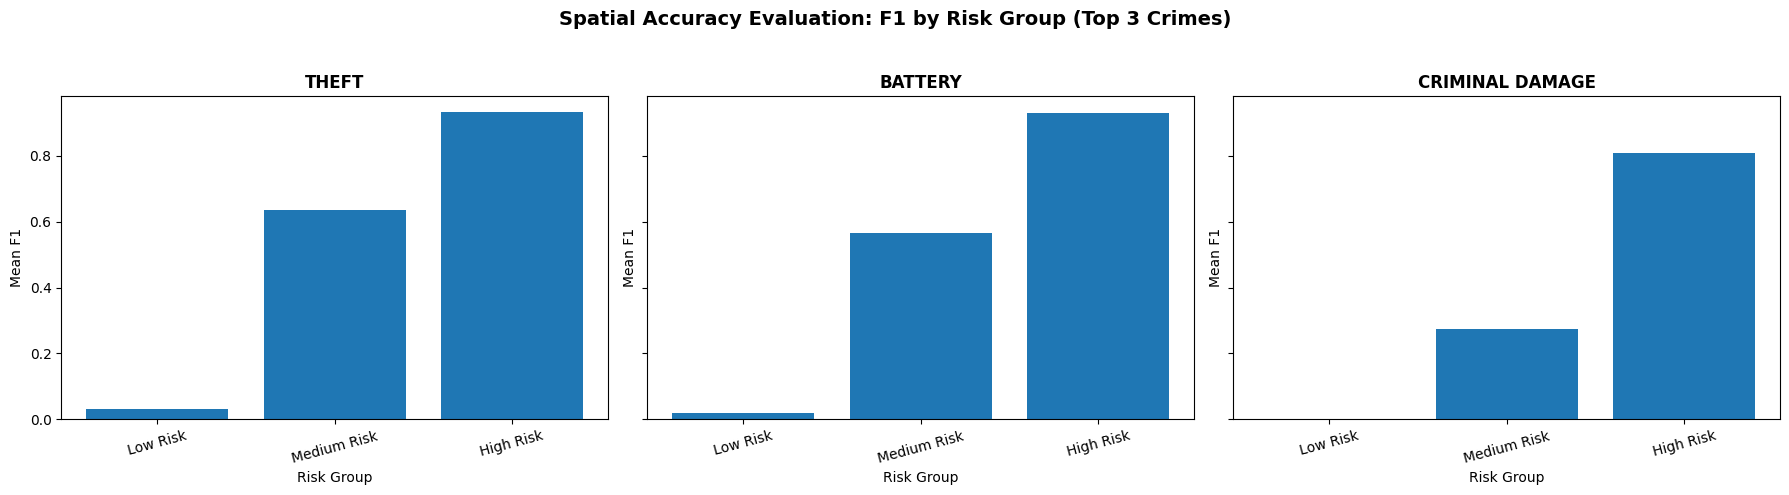

In [69]:
# One-row plot: spatial F1 by risk group for Top 3

target_display_names = {
    "label_THEFT": "THEFT",
    "label_BATTERY": "BATTERY",
    "label_CRIMINAL_DAMAGE": "CRIMINAL DAMAGE"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, target in zip(axes, top3_spatial_outputs.keys()):
    df_plot = top3_spatial_outputs[target]["risk_group_summary"]

    ax.bar(df_plot["risk_group"], df_plot["f1"])
    ax.set_title(target_display_names[target], fontsize=12, fontweight="bold")
    ax.set_xlabel("Risk Group")
    ax.set_ylabel("Mean F1")
    ax.tick_params(axis="x", labelrotation=15)

plt.suptitle("Spatial Accuracy Evaluation: F1 by Risk Group (Top 3 Crimes)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

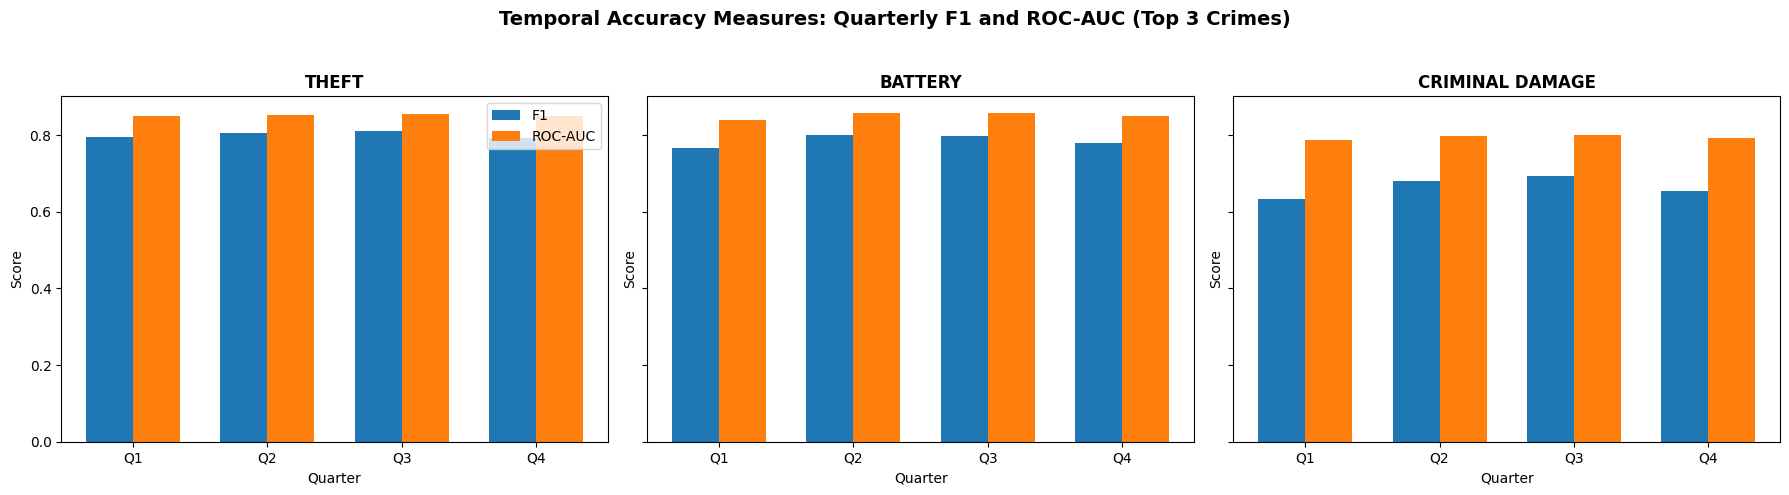

In [70]:
# One-row plot: quarterly temporal performance for Top 3

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, target in zip(axes, top3_temporal_outputs.keys()):
    df_plot = top3_temporal_outputs[target]["quarter_eval_df"]

    x = np.arange(len(df_plot))
    width = 0.35

    ax.bar(x - width/2, df_plot["f1"], width, label="F1")
    ax.bar(x + width/2, df_plot["roc_auc"], width, label="ROC-AUC")

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["quarter"])
    ax.set_title(target_display_names[target], fontsize=12, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Score")

axes[0].legend()
plt.suptitle("Temporal Accuracy Measures: Quarterly F1 and ROC-AUC (Top 3 Crimes)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [71]:
# Hotspot evaluation for Top 3 crimes
top3_hotspot_outputs = {}

for target, result_dict in top3_spatial_outputs.items():
    eval_df = result_dict["chicago_eval_df"]

    grid_summary, hotspot_metrics_df = compute_hotspot_metrics(
        eval_df,
        k_list=[5, 10, 20]
    )

    spatial_error_df = compute_spatial_error_by_grid(eval_df)

    top3_hotspot_outputs[target] = {
        "grid_summary": grid_summary,
        "hotspot_metrics_df": hotspot_metrics_df,
        "spatial_error_df": spatial_error_df
    }

    print("\n" + "=" * 80)
    print(f"Hotspot metrics - {target}")
    print("=" * 80)
    display(hotspot_metrics_df)


Hotspot metrics - label_THEFT


,k,hit_count,hit_rate,coverage
0,5,0,0.0,0.013572
1,10,3,0.3,0.027144
2,20,10,0.5,0.054288



Hotspot metrics - label_BATTERY


,k,hit_count,hit_rate,coverage
0,5,0,0.00,0.014057
1,10,4,0.40,0.028168
2,20,11,0.55,0.055955



Hotspot metrics - label_CRIMINAL_DAMAGE


,k,hit_count,hit_rate,coverage
0,5,4,0.8,0.017078
1,10,8,0.8,0.033534
2,20,12,0.6,0.064302


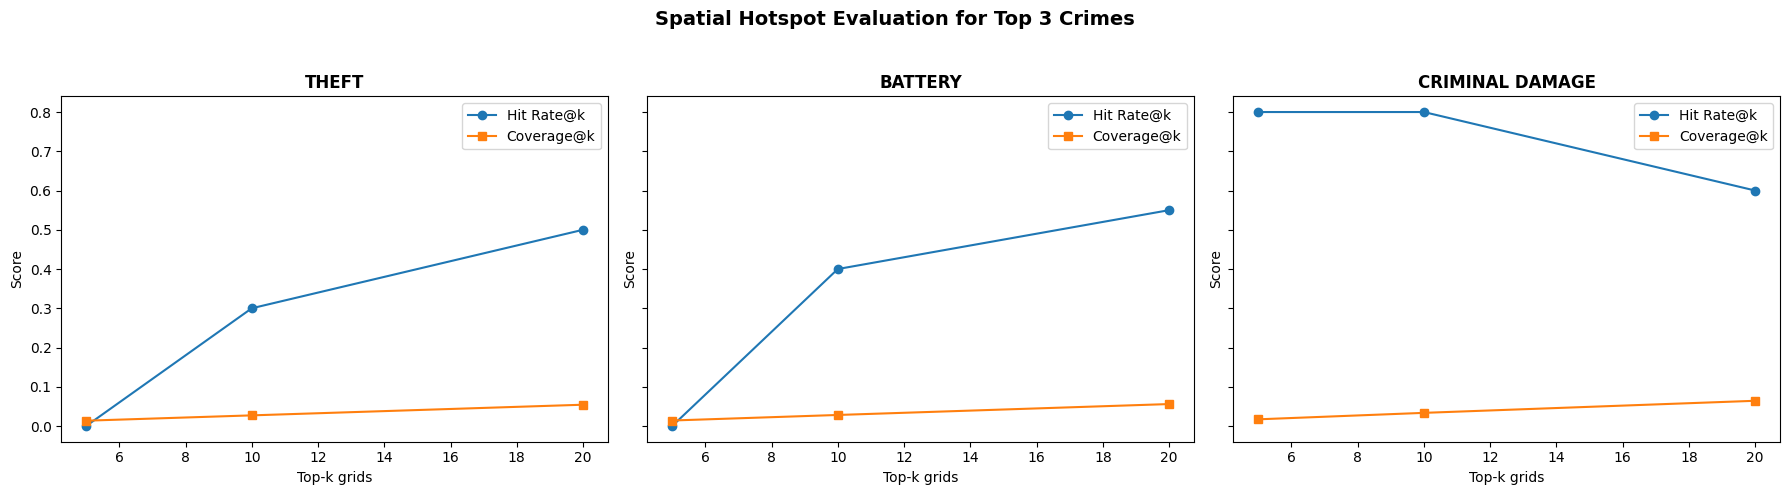

In [72]:
# Plot Hotspot Hit Rate@k for Top 3 crimes
target_display_names = {
    "label_THEFT": "THEFT",
    "label_BATTERY": "BATTERY",
    "label_CRIMINAL_DAMAGE": "CRIMINAL DAMAGE"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, target in zip(axes, top3_hotspot_outputs.keys()):
    df_plot = top3_hotspot_outputs[target]["hotspot_metrics_df"]

    ax.plot(df_plot["k"], df_plot["hit_rate"], marker="o", label="Hit Rate@k")
    ax.plot(df_plot["k"], df_plot["coverage"], marker="s", label="Coverage@k")

    ax.set_title(target_display_names[target], fontsize=12, fontweight="bold")
    ax.set_xlabel("Top-k grids")
    ax.set_ylabel("Score")
    ax.legend()

plt.suptitle("Spatial Hotspot Evaluation for Top 3 Crimes", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [73]:
#---------------------- TOTAL_CRIME spatial accuracy evaluation (Texas 2024)--------------------------------------------------------------------

In [74]:
# Texas external prediction table for spatial evaluation

texas_spatial_unit_col = get_texas_spatial_unit_col(ext_full)

texas_eval_df = ext_full[[texas_spatial_unit_col, "iso_year", "iso_week", "year_week"]].copy()
texas_eval_df["y_true"] = y_ext.values
texas_eval_df["y_pred"] = y_ext_pred
texas_eval_df["y_prob"] = y_ext_prob

texas_eval_df.head()

,agency_id,iso_year,iso_week,year_week,y_true,y_pred,y_prob
0,18753,2024,1,2024-W01,1,0,0.063761
1,18753,2024,2,2024-W02,1,0,0.087436
2,18753,2024,3,2024-W03,1,0,0.067495
3,18753,2024,4,2024-W04,1,0,0.056580
4,18753,2024,5,2024-W05,1,0,0.118463


In [75]:
# Spatial evaluation by Texas spatial unit

texas_spatial_eval_df = (
    texas_eval_df
    .groupby(texas_spatial_unit_col)
    .apply(safe_group_metrics)
    .reset_index()
)

texas_spatial_eval_df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\3061560604.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
0,18753,53.0,1.000000,0.773585,1.000000,0.773585,0.872340,NaN
1,18754,53.0,0.584906,0.566038,0.700000,0.451613,0.549020,0.476540
2,18756,53.0,0.735849,0.396226,0.684211,0.333333,0.448276,0.346154
3,18757,53.0,1.000000,0.773585,1.000000,0.773585,0.872340,NaN
4,18758,53.0,1.000000,0.754717,1.000000,0.754717,0.860215,NaN


In [76]:
# Best / worst Texas spatial units

texas_spatial_eval_filtered = texas_spatial_eval_df[texas_spatial_eval_df["n_samples"] >= 10].copy()

print("Top 10 Texas spatial units by F1:")
display(texas_spatial_eval_filtered.sort_values("f1", ascending=False).head(10))

print("Bottom 10 Texas spatial units by F1:")
display(texas_spatial_eval_filtered.sort_values("f1", ascending=True).head(10))

Top 10 Texas spatial units by F1:


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
1242,42552,53.0,0.490566,0.905660,1.00000,0.807692,0.893617,0.970085
1020,26289,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.903846
548,19395,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.788462
879,19767,53.0,0.943396,0.792453,0.97561,0.800000,0.879121,0.706667
275,19065,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN
284,19075,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN
762,19638,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN
282,19073,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN
279,19069,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN
768,19644,53.0,1.000000,0.773585,1.00000,0.773585,0.872340,NaN


Bottom 10 Texas spatial units by F1:


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
1258,44071,53.0,0.056604,0.943396,0.0,0.0,0.0,0.720000
944,19838,53.0,0.339623,0.660377,0.0,0.0,0.0,0.260317
1119,34171,53.0,0.113208,0.886792,0.0,0.0,0.0,0.606383
1120,34210,53.0,0.264151,0.735849,0.0,0.0,0.0,0.369963
936,19829,53.0,0.150943,0.849057,0.0,0.0,0.0,0.216667
518,19360,53.0,0.094340,0.905660,0.0,0.0,0.0,0.431250
1121,34396,53.0,0.301887,0.698113,0.0,0.0,0.0,0.314189
1122,34426,53.0,0.018868,0.981132,0.0,0.0,0.0,0.423077
1123,34434,53.0,0.358491,0.641509,0.0,0.0,0.0,0.447368
1118,34147,53.0,0.018868,0.981132,0.0,0.0,0.0,0.076923


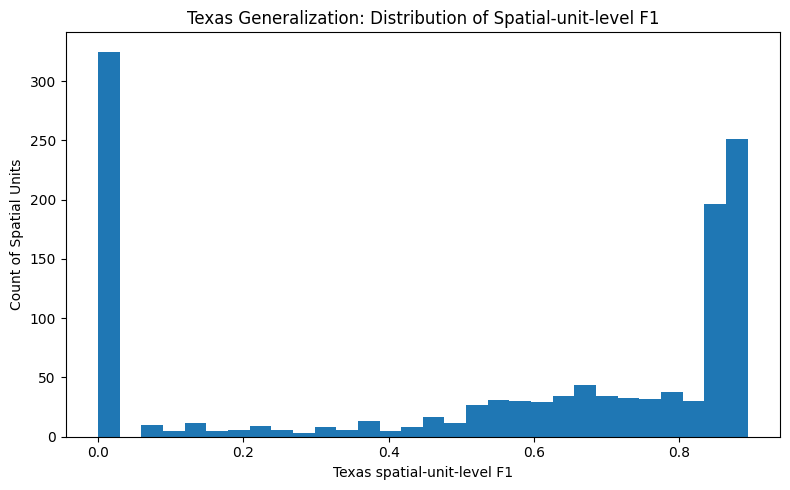

In [77]:
# Distribution of Texas spatial F1

plt.figure(figsize=(8, 5))
plt.hist(texas_spatial_eval_filtered["f1"].dropna(), bins=30)
plt.xlabel("Texas spatial-unit-level F1")
plt.ylabel("Count of Spatial Units")
plt.title("Texas Generalization: Distribution of Spatial-unit-level F1")
plt.tight_layout()
plt.show()

In [78]:
# Texas agency observed-risk grouping (post-hoc descriptive analysis)

texas_agency_risk = (
    texas_eval_df.groupby("agency_id")["y_true"]
    .mean()
    .reset_index()
    .rename(columns={"y_true": "observed_risk"})
)

texas_spatial_eval_with_risk = texas_spatial_eval_filtered.merge(
    texas_agency_risk,
    on="agency_id",
    how="left"
)

texas_spatial_eval_with_risk["risk_group"] = pd.qcut(
    texas_spatial_eval_with_risk["observed_risk"].rank(method="first"),
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

texas_risk_group_summary = (
    texas_spatial_eval_with_risk
    .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
    .mean()
    .reset_index()
)

display(texas_risk_group_summary)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\24444757.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.752381,0.103858,0.055302,0.067011,0.440600
1,Medium Risk,0.560229,0.805841,0.569221,0.664262,0.458414
2,High Risk,0.759299,0.998527,0.760023,0.862678,0.379310


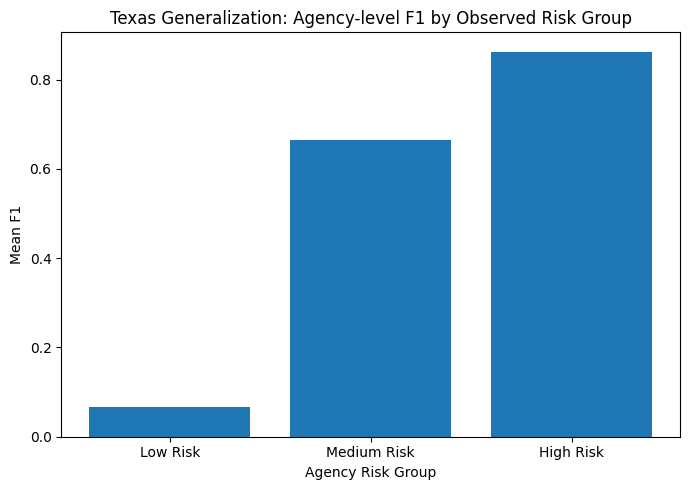

In [79]:
plt.figure(figsize=(7, 5))
plt.bar(texas_risk_group_summary["risk_group"], texas_risk_group_summary["f1"])
plt.xlabel("Agency Risk Group")
plt.ylabel("Mean F1")
plt.title("Texas Generalization: Agency-level F1 by Observed Risk Group")
plt.tight_layout()
plt.show()

In [80]:
#---------------------- Top_3_Crimes spatial accuracy evaluation (Texas 2024)--------------------------------------------------------------------

In [81]:
def build_texas_eval_df_for_target(target_col, model, ext_full, ext_X):
    eval_df = ext_full[["agency_id"]].copy()

    for col in ["iso_year", "iso_week", "year_week"]:
        if col in ext_full.columns:
            eval_df[col] = ext_full[col]

    eval_df["target"] = target_col
    eval_df["y_true"] = ext_full[target_col].values
    eval_df["y_pred"] = model.predict(ext_X)
    eval_df["y_prob"] = model.predict_proba(ext_X)[:, 1]

    return eval_df

In [82]:
def run_texas_spatial_evaluation_for_target(target_col, model, ext_full, ext_X):
    texas_eval_df = build_texas_eval_df_for_target(
        target_col=target_col,
        model=model,
        ext_full=ext_full,
        ext_X=ext_X
    )

    texas_spatial_eval_df = (
        texas_eval_df
        .groupby("agency_id")
        .apply(safe_group_metrics)
        .reset_index()
    )

    texas_spatial_eval_filtered = texas_spatial_eval_df[
        texas_spatial_eval_df["n_samples"] >= 10
    ].copy()

    return texas_eval_df, texas_spatial_eval_df, texas_spatial_eval_filtered

In [83]:
texas_top3_spatial_outputs = {}

for output in top3_outputs:
    target = output["target"]
    model = output["model"]

    print(f"\nRunning Texas agency-level spatial evaluation for {target} ...")

    texas_eval_df, texas_spatial_eval_df, texas_spatial_eval_filtered = run_texas_spatial_evaluation_for_target(
        target_col=target,
        model=model,
        ext_full=ext_full,
        ext_X=ext_X
    )

    texas_top3_spatial_outputs[target] = {
        "texas_eval_df": texas_eval_df,
        "texas_spatial_eval_df": texas_spatial_eval_df,
        "texas_spatial_eval_filtered": texas_spatial_eval_filtered
    }


Running Texas agency-level spatial evaluation for label_THEFT ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\726625392.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)



Running Texas agency-level spatial evaluation for label_BATTERY ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\726625392.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)



Running Texas agency-level spatial evaluation for label_CRIMINAL_DAMAGE ...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\726625392.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_group_metrics)


In [84]:
for target, result_dict in texas_top3_spatial_outputs.items():
    print("\n" + "=" * 80)
    print(f"Texas agency-level spatial summary - {target}")
    print("=" * 80)

    display(result_dict["texas_spatial_eval_filtered"].sort_values("f1", ascending=False).head(10))


Texas agency-level spatial summary - label_THEFT


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
384,19195,53.0,0.867925,0.811321,0.95000,0.826087,0.883721,0.835404
544,19391,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.903846
654,19518,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,1.000000
38,18795,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.788462
578,19429,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.788462
338,19144,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.942308
421,19241,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.826923
828,19713,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.980769
769,19645,53.0,0.981132,0.792453,1.00000,0.788462,0.881720,0.923077
253,19040,53.0,0.943396,0.792453,0.97561,0.800000,0.879121,0.733333



Texas agency-level spatial summary - label_BATTERY


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
88,18847,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
363,19171,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
207,18978,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
419,19239,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
834,19719,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
1009,25856,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
262,19052,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
386,19197,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
827,19712,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN
815,19700,53.0,1.0,0.773585,1.0,0.773585,0.87234,NaN



Texas agency-level spatial summary - label_CRIMINAL_DAMAGE


,agency_id,n_samples,positive_rate,accuracy,precision,recall,f1,roc_auc
539,19386,53.0,1.000000,0.754717,1.000000,0.754717,0.860215,NaN
419,19239,53.0,1.000000,0.735849,1.000000,0.735849,0.847826,NaN
91,18850,53.0,1.000000,0.735849,1.000000,0.735849,0.847826,NaN
111,18873,53.0,1.000000,0.716981,1.000000,0.716981,0.835165,NaN
88,18847,53.0,1.000000,0.716981,1.000000,0.716981,0.835165,NaN
99,18858,53.0,0.962264,0.716981,0.973684,0.725490,0.831461,0.588235
792,19674,53.0,1.000000,0.698113,1.000000,0.698113,0.822222,NaN
513,19354,53.0,0.981132,0.698113,0.973684,0.711538,0.822222,0.365385
188,18958,53.0,0.924528,0.716981,1.000000,0.693878,0.819277,0.852041
828,19713,53.0,0.943396,0.698113,1.000000,0.680000,0.809524,0.926667


In [85]:
# Texas Top 3: observed-risk grouping summary for each crime

texas_top3_risk_outputs = {}

for target, result_dict in texas_top3_spatial_outputs.items():
    texas_eval_df = result_dict["texas_eval_df"]
    texas_spatial_eval_filtered = result_dict["texas_spatial_eval_filtered"]

    texas_agency_risk = (
        texas_eval_df.groupby("agency_id")["y_true"]
        .mean()
        .reset_index()
        .rename(columns={"y_true": "observed_risk"})
    )

    texas_spatial_eval_with_risk = texas_spatial_eval_filtered.merge(
        texas_agency_risk,
        on="agency_id",
        how="left"
    )

    texas_spatial_eval_with_risk["risk_group"] = pd.qcut(
        texas_spatial_eval_with_risk["observed_risk"].rank(method="first"),
        q=3,
        labels=["Low Risk", "Medium Risk", "High Risk"]
    )

    texas_risk_group_summary = (
        texas_spatial_eval_with_risk
        .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
        .mean()
        .reset_index()
    )

    texas_top3_risk_outputs[target] = {
        "texas_agency_risk": texas_agency_risk,
        "texas_spatial_eval_with_risk": texas_spatial_eval_with_risk,
        "texas_risk_group_summary": texas_risk_group_summary
    }

    print("\n" + "=" * 80)
    print(f"Texas agency observed-risk summary - {target}")
    print("=" * 80)
    display(texas_risk_group_summary)


Texas agency observed-risk summary - label_THEFT


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\234432625.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.959119,0.000325,0.001786,0.000549,0.453876
1,Medium Risk,0.644977,0.233062,0.149054,0.170742,0.473546
2,High Risk,0.716846,0.923921,0.747499,0.825379,0.449274



Texas agency observed-risk summary - label_BATTERY


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\234432625.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.939892,0.000216,0.000397,0.000280,0.449031
1,Medium Risk,0.622506,0.164889,0.089731,0.108451,0.475221
2,High Risk,0.599371,0.894197,0.608459,0.721595,0.431131



Texas agency observed-risk summary - label_CRIMINAL_DAMAGE


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30196\234432625.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")[["accuracy", "precision", "recall", "f1", "roc_auc"]]


,risk_group,accuracy,precision,recall,f1,roc_auc
0,Low Risk,0.982794,0.000000,0.000000,0.000000,0.413694
1,Medium Risk,0.807943,0.041891,0.029646,0.029956,0.477670
2,High Risk,0.534951,0.694926,0.469833,0.553292,0.491935


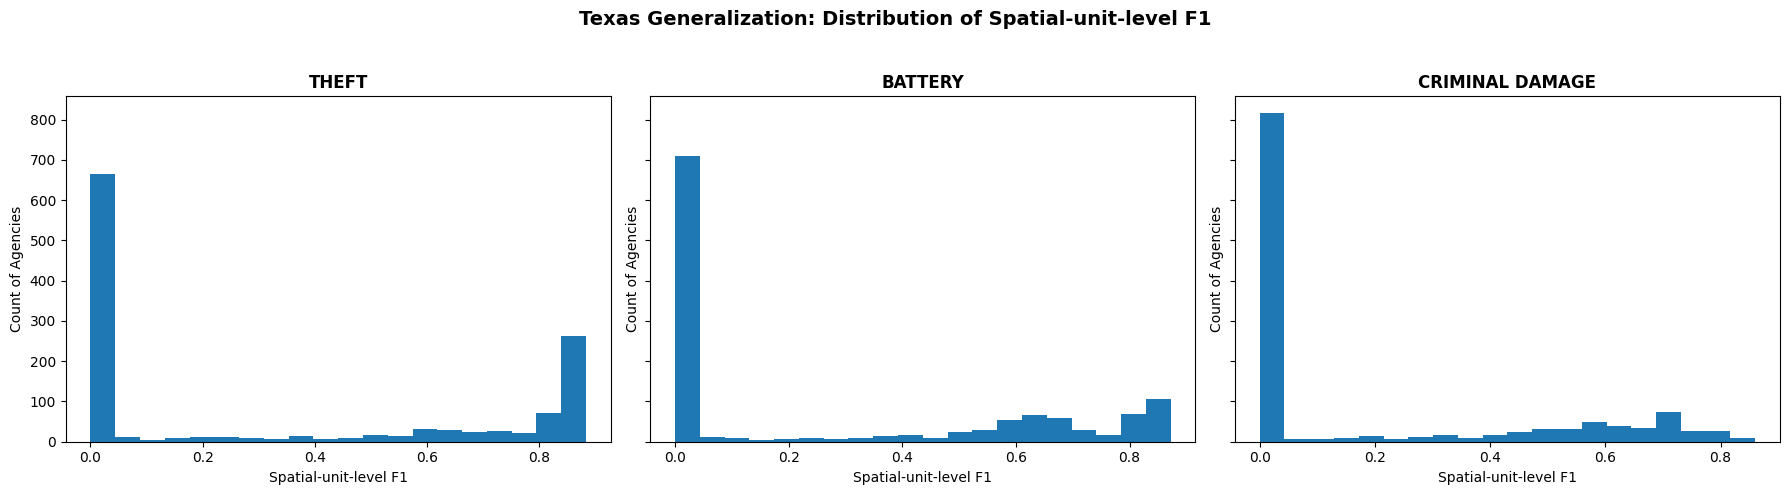

In [86]:
# Texas Top 3: Distribution of Spatial-unit-level F1

target_display_names = {
    "label_THEFT": "THEFT",
    "label_BATTERY": "BATTERY",
    "label_CRIMINAL_DAMAGE": "CRIMINAL DAMAGE"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, target in zip(axes, texas_top3_spatial_outputs.keys()):
    df_plot = texas_top3_spatial_outputs[target]["texas_spatial_eval_filtered"]

    ax.hist(df_plot["f1"].dropna(), bins=20)
    ax.set_title(target_display_names.get(target, target), fontsize=12, fontweight="bold")
    ax.set_xlabel("Spatial-unit-level F1")
    ax.set_ylabel("Count of Agencies")

plt.suptitle("Texas Generalization: Distribution of Spatial-unit-level F1", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

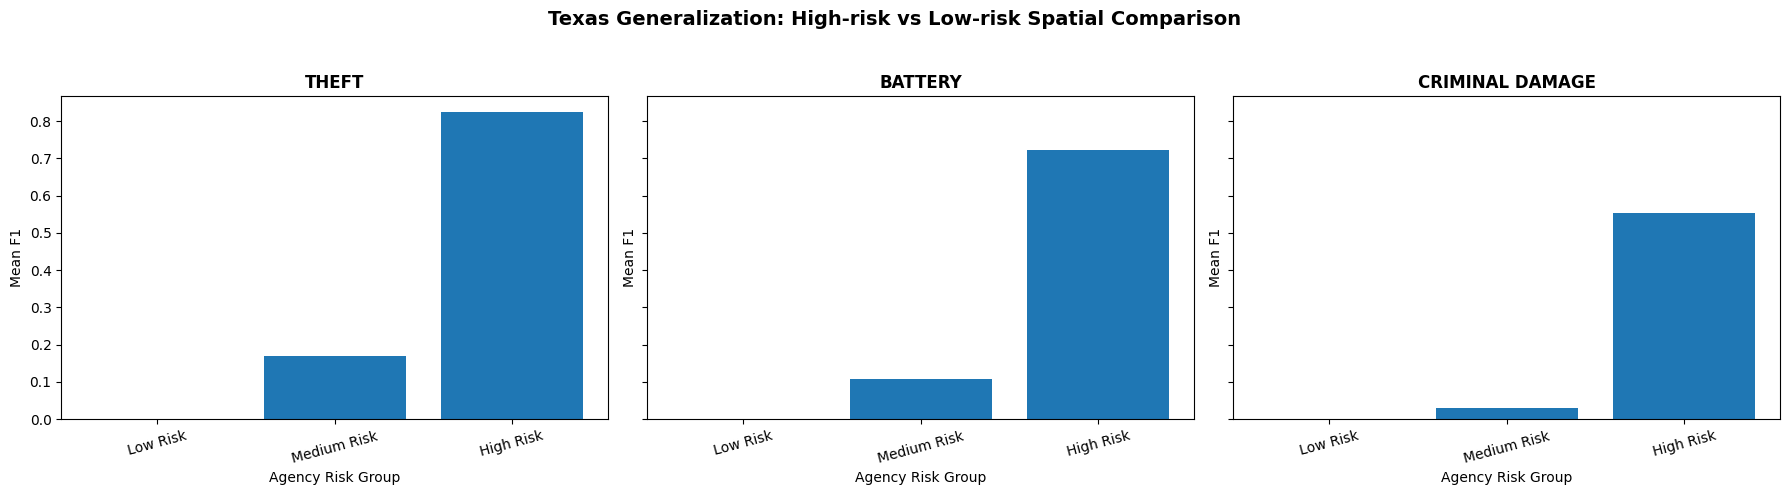

In [87]:
# Texas Top 3: High-risk vs Low-risk comparison plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, target in zip(axes, texas_top3_risk_outputs.keys()):
    df_plot = texas_top3_risk_outputs[target]["texas_risk_group_summary"]

    ax.bar(df_plot["risk_group"], df_plot["f1"])
    ax.set_title(target_display_names.get(target, target), fontsize=12, fontweight="bold")
    ax.set_xlabel("Agency Risk Group")
    ax.set_ylabel("Mean F1")
    ax.tick_params(axis="x", labelrotation=15)

plt.suptitle("Texas Generalization: High-risk vs Low-risk Spatial Comparison", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()